# Exploratory Data Analysis (EDA)
**Project:** GreenThumb AI – Knowledge-Verified Plant Disease Detection  
**Dataset:** PlantVillage (Color Images)  
**Objective:** Understand dataset structure, class distribution, and image properties


## Importing Libraries

In [ ]:
import os
import random
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [2]:
# Reproducibility
random.seed(42)
np.random.seed(42)

# Plot style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Setting up clear Data Path

In [14]:
DATASET_ROOT = "../data/plantvillage dataset/color"
PLOT_PATH = "../outputs/plots/"

assert os.path.exists(DATASET_ROOT), "Dataset path not found!"
print("Dataset path verified:", DATASET_ROOT)
assert os.path.exists(PLOT_PATH), "Plot path not found!"
print("Plot path verified:", PLOT_PATH)

Dataset path verified: ../data/plantvillage dataset/color
Plot path verified: ../outputs/plots/


## Dataset Sanity Check

In [5]:
class_dirs = sorted([d for d in os.listdir(DATASET_ROOT)
                     if os.path.isdir(os.path.join(DATASET_ROOT, d))])

num_classes = len(class_dirs)
print(f"Number of classes: {num_classes}")

Number of classes: 38


In [8]:
image_counts = {}
total_images = 0

for cls in class_dirs:
    cls_path = os.path.join(DATASET_ROOT, cls)
    images = glob(os.path.join(cls_path, "*.jpg"))
    image_counts[cls] = len(images)
    total_images += len(images)

print(f"Total images: {total_images}")
f"Total Images in each class: {image_counts}"

Total images: 54303


"Total Images in each class: {'Apple___Apple_scab': 630, 'Apple___Black_rot': 621, 'Apple___Cedar_apple_rust': 275, 'Apple___healthy': 1645, 'Blueberry___healthy': 1502, 'Cherry_(including_sour)___Powdery_mildew': 1052, 'Cherry_(including_sour)___healthy': 854, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 513, 'Corn_(maize)___Common_rust_': 1192, 'Corn_(maize)___Northern_Leaf_Blight': 985, 'Corn_(maize)___healthy': 1162, 'Grape___Black_rot': 1180, 'Grape___Esca_(Black_Measles)': 1383, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1076, 'Grape___healthy': 423, 'Orange___Haunglongbing_(Citrus_greening)': 5507, 'Peach___Bacterial_spot': 2297, 'Peach___healthy': 360, 'Pepper,_bell___Bacterial_spot': 997, 'Pepper,_bell___healthy': 1477, 'Potato___Early_blight': 1000, 'Potato___Late_blight': 1000, 'Potato___healthy': 152, 'Raspberry___healthy': 371, 'Soybean___healthy': 5090, 'Squash___Powdery_mildew': 1835, 'Strawberry___Leaf_scorch': 1109, 'Strawberry___healthy': 456, 'Tomato___Ba

In [7]:
# Check empty folders
empty_classes = [cls for cls, cnt in image_counts.items() if cnt == 0]
print("Empty class folders:", empty_classes)

Empty class folders: []


## Class Distribution Analysis

In [9]:
df_counts = pd.DataFrame.from_dict(
    image_counts, orient="index", columns=["num_images"]
).sort_values(by="num_images", ascending=False)

df_counts.head()

,num_images
Orange___Haunglongbing_(Citrus_greening),5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
Soybean___healthy,5090
Peach___Bacterial_spot,2297
Tomato___Bacterial_spot,2127


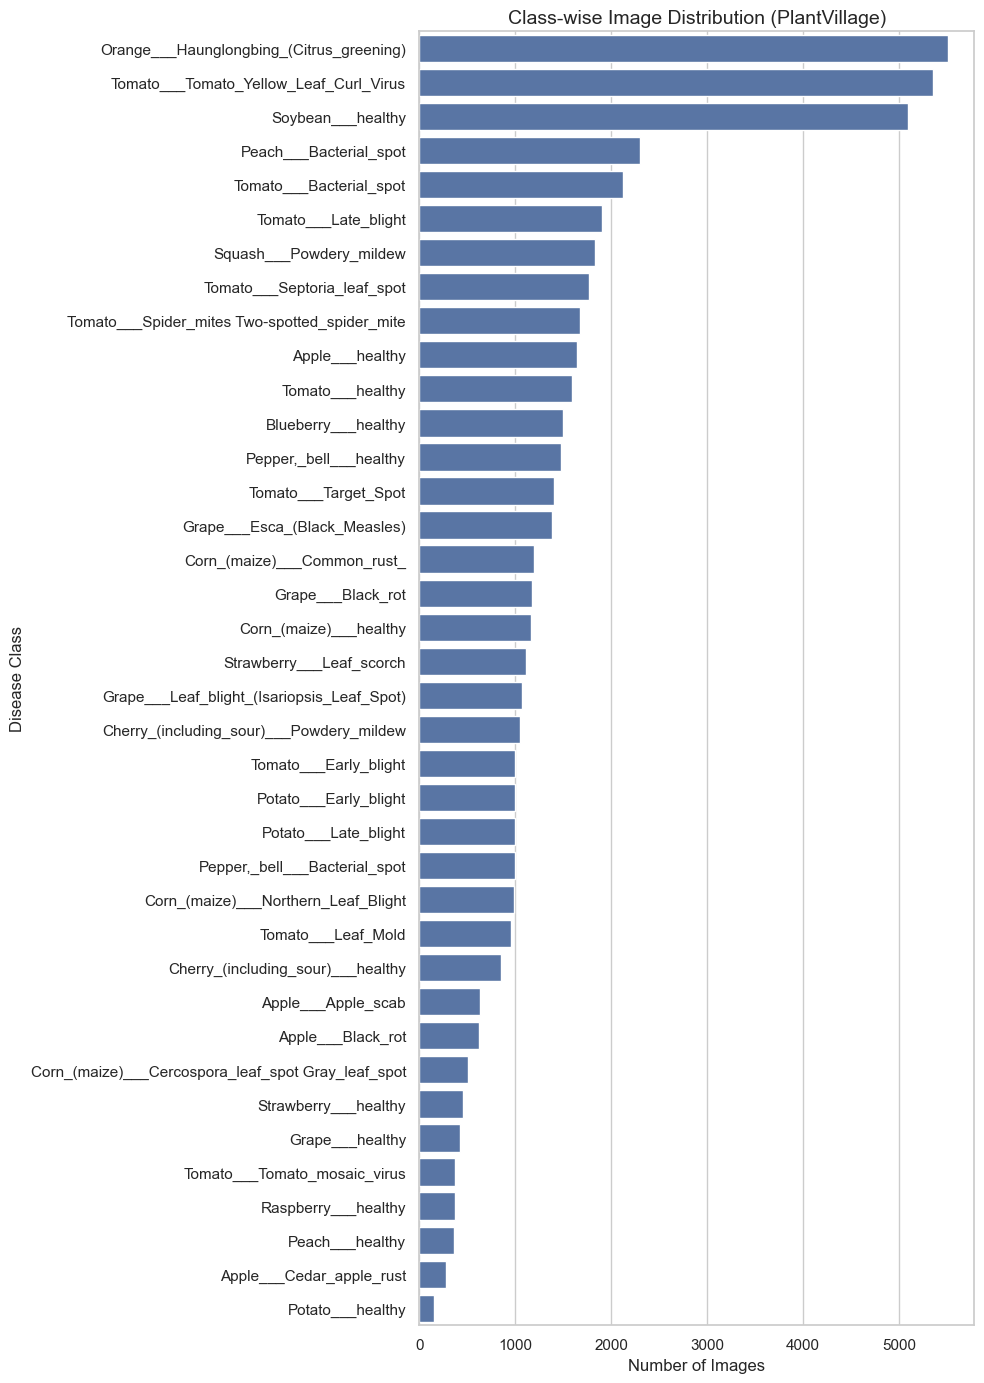

In [37]:
plt.figure(figsize=(10, 14))  # taller figure
sns.barplot(
    x=df_counts["num_images"],
    y=df_counts.index,
    orient="h"
)

plt.title("Class-wise Image Distribution (PlantVillage)", fontsize=14)
plt.xlabel("Number of Images")
plt.ylabel("Disease Class")
plt.tight_layout()

plt.savefig(
    f"{PLOT_PATH}/Class-wise_Image_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Sample Image Visualization

In [27]:
def show_sample_images(dataset_root, classes, samples_per_class=2):
    plt.figure(figsize=(12, 12))
    plot_idx = 1

    for cls in classes[:6]:  # limit for readability
        cls_path = os.path.join(dataset_root, cls)
        images = glob(os.path.join(cls_path, "*.jpg"))

        for img_path in random.sample(images, samples_per_class):
            img = Image.open(img_path)
            plt.subplot(6, samples_per_class, plot_idx)
            plt.imshow(img)
            plt.axis("off")
            plt.title(cls.replace("___", "\n"), fontsize=8)
            plot_idx += 1

    plt.tight_layout()
    plt.show()

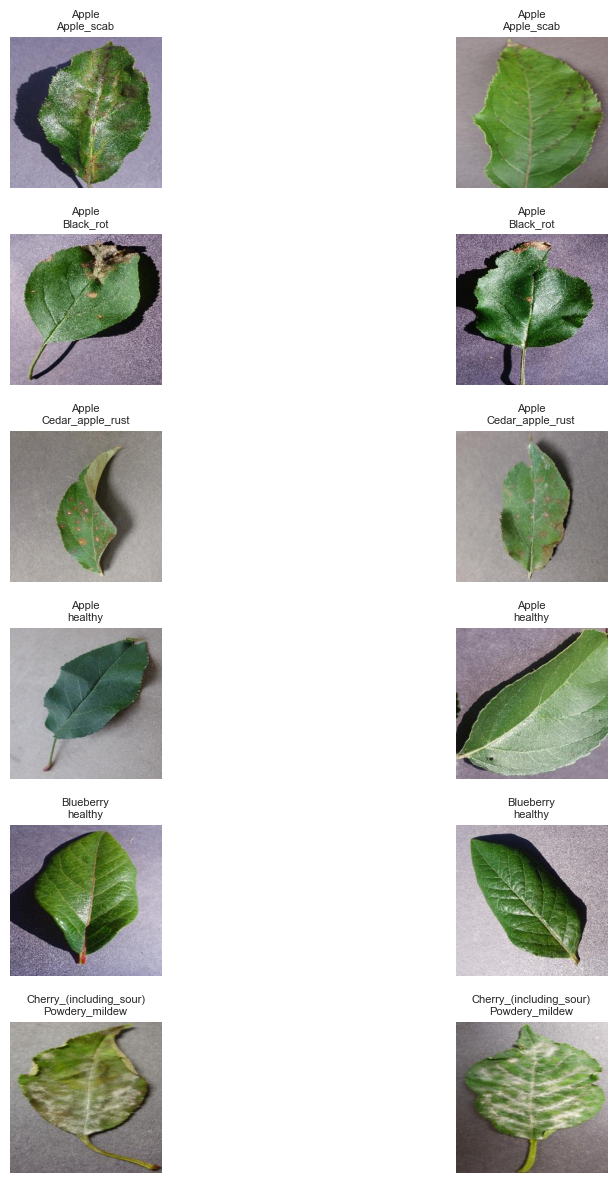

In [28]:
show_sample_images(DATASET_ROOT, class_dirs)

## Image Property Analysis

In [29]:
image_sizes = []

for cls in class_dirs:
    img_path = glob(os.path.join(DATASET_ROOT, cls, "*.jpg"))[0]
    with Image.open(img_path) as img:
        image_sizes.append(img.size)

In [30]:
sizes_df = pd.DataFrame(image_sizes, columns=["width", "height"])
sizes_df.describe()

,width,height
count,38.0,38.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


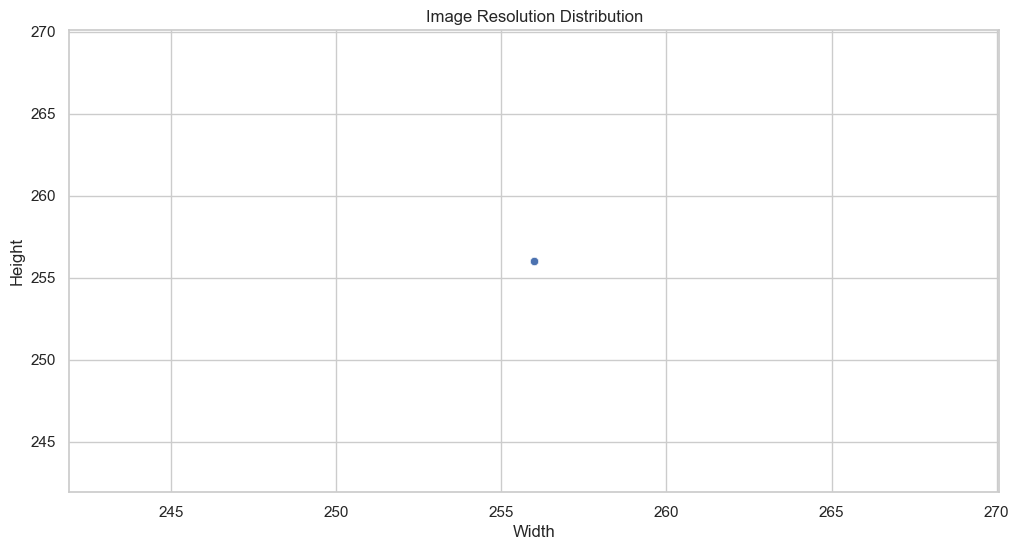

In [31]:
sns.scatterplot(x=sizes_df["width"], y=sizes_df["height"])
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


##  Channel Verification (RGB Check)

In [32]:
img_path = glob(os.path.join(DATASET_ROOT, class_dirs[0], "*.jpg"))[0]
img = Image.open(img_path)

print("Image mode:", img.mode)
print("Image size:", img.size)

Image mode: RGB
Image size: (256, 256)


## EDA OBSERVATION


### Key Observations from EDA

- The PlantVillage dataset contains approximately 38 disease classes with noticeable class imbalance.
- All images are high-quality, lab-controlled leaf images.
- Color (RGB) images preserve important disease-related visual features.
- Image resolutions vary, requiring uniform resizing during preprocessing.
- Stratified train–validation–test splitting is necessary to handle imbalance.
- The dataset is suitable for benchmarking but may not fully represent real-world field conditions.


### Conclusion and Next Steps

Based on the exploratory analysis, we proceed with:
- Using **color images only**
- Applying **data augmentation** to mitigate class imbalance
- Resizing images to a fixed resolution (224×224)
- Using **stratified splits** for training, validation, and testing

Next, we will implement the data loading and augmentation pipeline in **Notebook 02**.